# Experiments — MLP From Scratch

## 1. Validation: XOR + Gradient Check

Before MNIST, we validate the network on the smallest non-linear problem (XOR)
and verify backpropagation by comparing the analytic gradient to a numeric one.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # import the `mlp` package from the repo root

import numpy as np
import matplotlib.pyplot as plt

from mlp.network import MLP
from mlp.activations import softmax
from mlp.losses import cross_entropy
from mlp.optimizers import SGD, Adam

np.random.seed(0)

In [2]:
# XOR: output is 1 when the inputs differ. Not linearly separable ->
# only a network with hidden layer(s) can solve it.
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_labels = np.array([0, 1, 1, 0])

# One-hot (2 classes) to match softmax + cross-entropy.
y_xor = np.eye(2)[y_labels]
print("X:\n", X_xor)
print("y (one-hot):\n", y_xor)

X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y (one-hot):
 [[1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]


### Gradient check

The numeric gradient approximates `dL/dparam` from the definition of a derivative:
`(L(p + e) - L(p - e)) / (2e)`. If backprop is correct, analytic and numeric
gradients must match (difference < 1e-5).

In [3]:
def gradient_check(net, X, y, epsilon=1e-5):
    """Compare the analytic gradient (backprop) with the numeric one."""
    # Analytic gradient (what we want to validate).
    net.forward(X)
    grads_W, grads_b = net.backward(y)

    def loss_at():
        return cross_entropy(softmax(net.forward(X)), y)

    max_diff = 0.0
    # Check every weight, element by element.
    for layer in range(len(net.weights)):
        W = net.weights[layer]
        for idx in np.ndindex(W.shape):
            original = W[idx]

            W[idx] = original + epsilon
            loss_plus = loss_at()
            W[idx] = original - epsilon
            loss_minus = loss_at()
            W[idx] = original  # restore

            numeric = (loss_plus - loss_minus) / (2 * epsilon)
            analytic = grads_W[layer][idx]
            max_diff = max(max_diff, abs(numeric - analytic))

    return max_diff


net_check = MLP([2, 4, 2], activations=["relu"], seed=1)
diff = gradient_check(net_check, X_xor, y_xor)
print(f"Max analytic-vs-numeric difference: {diff:.2e}")
print("BACKPROP CORRECT!" if diff < 1e-5 else "SOMETHING IS WRONG in backward.")

Max analytic-vs-numeric difference: 6.39e-12
BACKPROP CORRECT!


Final loss: 0.0002745415543306413
Predictions: [0 1 1 0] | Expected: [0 1 1 0]


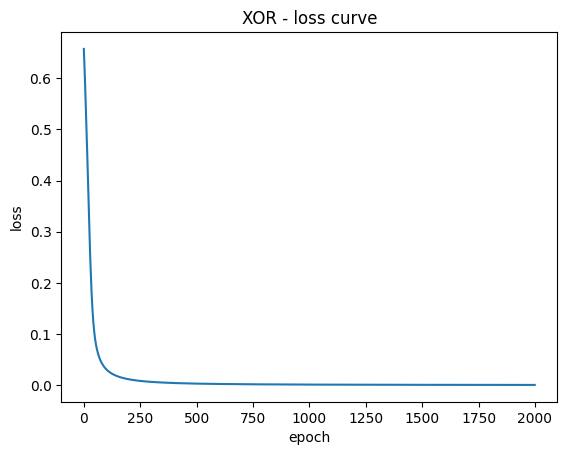

In [4]:
# Train on XOR to prove the network learns end-to-end.
net = MLP([2, 8, 8, 2], activations=["relu", "relu"], seed=42)
opt = Adam(lr=0.01)

losses = []
for epoch in range(2000):
    logits = net.forward(X_xor)
    loss = cross_entropy(softmax(logits), y_xor)
    losses.append(loss)

    grads_W, grads_b = net.backward(y_xor)
    opt.step(net.weights, net.biases, grads_W, grads_b)

print("Final loss:", losses[-1])
print("Predictions:", net.predict(X_xor), "| Expected:", y_labels)

plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("XOR - loss curve")
plt.show()

## 2. MNIST — Data & Training

Now we scale the validated network to MNIST (10 handwritten digits). We load the
data, flatten each 28x28 image into a 784-vector, normalize pixels to `[0, 1]`,
one-hot the labels, and train with mini-batch SGD. Target: test accuracy >= 92%.

In [5]:
import urllib.request


def load_mnist(path="../data/mnist.npz"):
    """Download MNIST (same .npz keras uses) and load it with NumPy."""
    url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
    os.makedirs(os.path.dirname(path), exist_ok=True)
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
    with np.load(path) as f:
        return (f["x_train"], f["y_train"]), (f["x_test"], f["y_test"])


(x_train, y_train), (x_test, y_test) = load_mnist()

# Preprocess: flatten 28x28 -> 784, scale pixels to [0, 1], one-hot the labels.
X_train = x_train.reshape(-1, 784) / 255.0
X_test = x_test.reshape(-1, 784) / 255.0
Y_train = np.eye(10)[y_train]   # one-hot, used by the loss
# y_train / y_test stay as integer labels, used for accuracy.
print("X_train", X_train.shape, "| X_test", X_test.shape)

X_train (60000, 784) | X_test (10000, 784)


In [6]:
def accuracy(net, X, labels):
    return (net.predict(X) == labels).mean()


def train(net, opt, X, Y, labels, X_val, y_val, epochs, batch_size, seed=0, verbose=True):
    """Mini-batch training loop. Returns history for plotting."""
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    history = {"loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # Shuffle every epoch so batches differ -> the 'stochastic' in SGD.
        perm = rng.permutation(n)
        X_shuf, Y_shuf = X[perm], Y[perm]

        batch_losses = []
        for start in range(0, n, batch_size):
            xb = X_shuf[start:start + batch_size]
            yb = Y_shuf[start:start + batch_size]

            logits = net.forward(xb)
            batch_losses.append(cross_entropy(softmax(logits), yb))
            grads_W, grads_b = net.backward(yb)
            opt.step(net.weights, net.biases, grads_W, grads_b)

        history["loss"].append(float(np.mean(batch_losses)))
        history["train_acc"].append(accuracy(net, X, labels))
        history["val_acc"].append(accuracy(net, X_val, y_val))
        if verbose:
            print(f"epoch {epoch:2d} | loss {history['loss'][-1]:.4f} "
                  f"| train {history['train_acc'][-1]:.4f} | test {history['val_acc'][-1]:.4f}")

    return history

In [7]:
# Main model: 784 -> 128 -> 64 -> 10, ReLU hidden layers, SGD mini-batches.
net = MLP([784, 128, 64, 10], activations=["relu", "relu"], seed=42)
opt = SGD(lr=0.1)

history = train(net, opt, X_train, Y_train, y_train, X_test, y_test,
                epochs=15, batch_size=64)

print("\nFinal test accuracy:", round(accuracy(net, X_test, y_test), 4))

epoch  0 | loss 0.3260 | train 0.9538 | test 0.9527
epoch  1 | loss 0.1495 | train 0.9626 | test 0.9576
epoch  2 | loss 0.1054 | train 0.9771 | test 0.9722
epoch  3 | loss 0.0832 | train 0.9738 | test 0.9626
epoch  4 | loss 0.0675 | train 0.9831 | test 0.9737
epoch  5 | loss 0.0561 | train 0.9875 | test 0.9750
epoch  6 | loss 0.0476 | train 0.9896 | test 0.9765
epoch  7 | loss 0.0411 | train 0.9915 | test 0.9773
epoch  8 | loss 0.0342 | train 0.9908 | test 0.9738
epoch  9 | loss 0.0285 | train 0.9937 | test 0.9764
epoch 10 | loss 0.0241 | train 0.9950 | test 0.9786
epoch 11 | loss 0.0207 | train 0.9906 | test 0.9734
epoch 12 | loss 0.0174 | train 0.9975 | test 0.9787
epoch 13 | loss 0.0143 | train 0.9976 | test 0.9791
epoch 14 | loss 0.0121 | train 0.9986 | test 0.9781

Final test accuracy: 0.9781


## 3. Training Curves

Loss and accuracy of the main model over the epochs. The loss should fall
steadily while train/test accuracy rise and stay close (little overfitting).

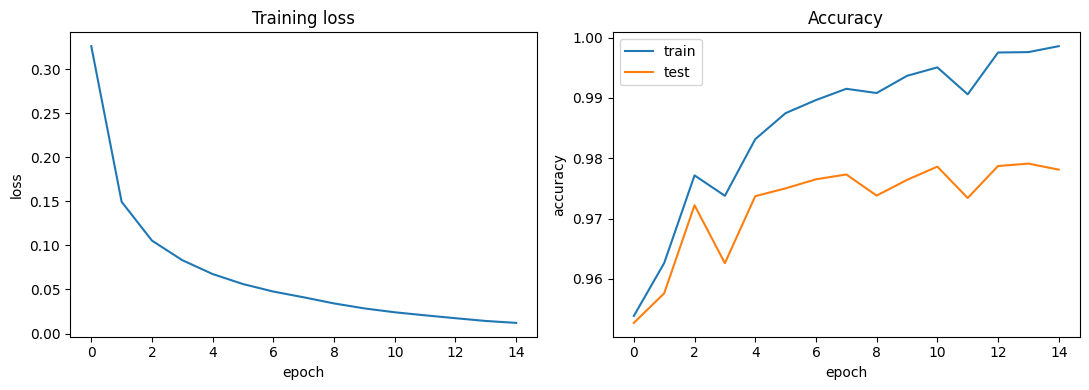

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(history["loss"])
ax1.set_title("Training loss"); ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")

ax2.plot(history["train_acc"], label="train")
ax2.plot(history["val_acc"], label="test")
ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend()

fig.tight_layout()
fig.savefig("../results/training_curves.png", dpi=120)
plt.show()

## 4. Experiment Comparison

We compare at least two different configurations, varying one factor at a time:
learning rate, activation function, optimizer and network depth. Each model
trains for 10 epochs so the comparison is fair.

In [9]:
# Compare configurations: vary learning rate, activation, optimizer and depth.
experiments = {
    "A: [128,64] relu, SGD lr=0.1":   lambda: (MLP([784, 128, 64, 10], ["relu", "relu"], seed=42), SGD(lr=0.1)),
    "B: [128,64] relu, SGD lr=0.01":  lambda: (MLP([784, 128, 64, 10], ["relu", "relu"], seed=42), SGD(lr=0.01)),
    "C: [128,64] tanh, SGD lr=0.1":   lambda: (MLP([784, 128, 64, 10], ["tanh", "tanh"], seed=42), SGD(lr=0.1)),
    "D: [128,64] relu, Adam lr=1e-3": lambda: (MLP([784, 128, 64, 10], ["relu", "relu"], seed=42), Adam(lr=0.001)),
    "E: [256] relu, SGD lr=0.1":      lambda: (MLP([784, 256, 10], ["relu"], seed=42), SGD(lr=0.1)),
}

results = {}
for name, make in experiments.items():
    net_i, opt_i = make()
    hist = train(net_i, opt_i, X_train, Y_train, y_train, X_test, y_test,
                 epochs=10, batch_size=64, verbose=False)
    results[name] = hist
    print(f"{name:34s} final test acc = {hist['val_acc'][-1]:.4f}")

A: [128,64] relu, SGD lr=0.1       final test acc = 0.9764
B: [128,64] relu, SGD lr=0.01      final test acc = 0.9531
C: [128,64] tanh, SGD lr=0.1       final test acc = 0.9755
D: [128,64] relu, Adam lr=1e-3     final test acc = 0.9769
E: [256] relu, SGD lr=0.1          final test acc = 0.9772


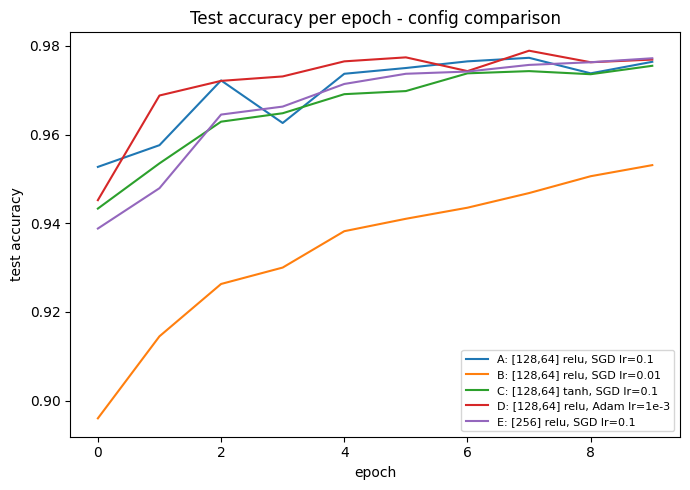

In [10]:
plt.figure(figsize=(7, 5))
for name, hist in results.items():
    plt.plot(hist["val_acc"], label=name)
plt.title("Test accuracy per epoch - config comparison")
plt.xlabel("epoch"); plt.ylabel("test accuracy"); plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../results/comparison.png", dpi=120)
plt.show()

## 5. Confusion Matrix

Where does the model still make mistakes? The confusion matrix shows, for each
true digit, what the model predicted. The diagonal is correct; off-diagonal
cells are errors. We also print the most-confused pairs.

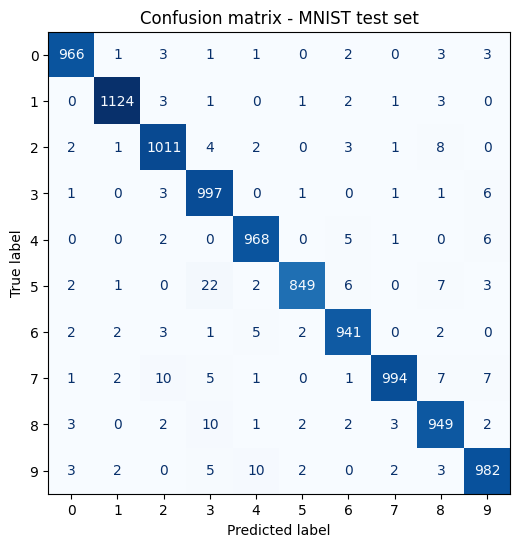

Most confused pairs (true -> predicted):
  5 predicted as 3: 22 times
  7 predicted as 2: 10 times
  8 predicted as 3: 10 times
  9 predicted as 4: 10 times


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix of the main model (`net`) on the test set.
y_pred = net.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix - MNIST test set")
fig.savefig("../results/confusion_matrix.png", dpi=120)
plt.show()

# Which digits does the model confuse the most?
off = cm.copy()
np.fill_diagonal(off, 0)  # ignore correct predictions
print("Most confused pairs (true -> predicted):")
for _ in range(4):
    i, j = np.unravel_index(off.argmax(), off.shape)
    print(f"  {i} predicted as {j}: {off[i, j]} times")
    off[i, j] = 0